# Introduction to Action-Angle Coordinates

Action-angle coordinates $(\mathbf{J}, \boldsymbol{\theta})$ are canonical
coordinates for integrable Hamiltonian systems in which the actions $\mathbf{J}$
are constants of motion and the angles $\boldsymbol{\theta}$ increase linearly
with time at rates given by the frequencies $\boldsymbol{\Omega}$.

For an axisymmetric potential, the three actions are:
- $J_R$: radial action (related to the radial oscillation amplitude)
- $L_z$: z-component of angular momentum (azimuthal action)
- $J_z$: vertical action (related to the vertical oscillation amplitude)

The corresponding frequencies are $\Omega_R$, $\Omega_\phi$, and $\Omega_z$.

galpy supports both **forward** transformations $(\mathbf{x}, \mathbf{v}) \to (\mathbf{J}, \boldsymbol{\theta}, \boldsymbol{\Omega})$
and **inverse** transformations $(\mathbf{J}, \boldsymbol{\theta}) \to (\mathbf{x}, \mathbf{v})$.

In [1]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Using the Orbit interface

The simplest way to compute actions, frequencies, and angles is through
the `Orbit` class. After integrating an orbit, you can call methods like
`o.jr()`, `o.jp()`, `o.jz()` for actions, `o.Or()`, `o.Op()`, `o.Oz()`
for frequencies, and `o.wr()`, `o.wp()`, `o.wz()` for angles. Or you
can call these without first integrating the orbit, but specifying the potential
``pot=`` (the orbit integration itself is not used to compute the actions, frequencies, 
or angles).

These methods automatically select an appropriate action-angle calculator
based on the potential.

In [2]:
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014

o = Orbit([1.0, 0.1, 1.1, 0.0, 0.05, 0.0])

# Actions
print("J_R  =", o.jr(pot=MWPotential2014))
print("L_z  =", o.jp(pot=MWPotential2014))
print("J_z  =", o.jz(pot=MWPotential2014))

J_R  = 0.013601590561180018
L_z  = 1.1
J_z  = 0.00046419497750607437


Frequencies tell us the rate at which angles increase:

In [3]:
# Frequencies
print("Omega_R   =", o.Or(pot=MWPotential2014))
print("Omega_phi =", o.Op(pot=MWPotential2014))
print("Omega_z   =", o.Oz(pot=MWPotential2014))

Omega_R   = 1.1594952066862576
Omega_phi = 0.8684785132615731
Omega_z   = 2.221827947295238


And the angles at the initial time:

In [4]:
# Angles (at the initial time)
print("theta_R   =", o.wr(pot=MWPotential2014))
print("theta_phi =", o.wp(pot=MWPotential2014))
print("theta_z   =", o.wz(pot=MWPotential2014))

theta_R   = 0.46956828125248784
theta_phi = 6.176670459451017
theta_z   = 6.0941871525180344


## Isochrone potential: exact action-angle coordinates

The isochrone potential is special because it has exact analytical
action-angle coordinates. This makes it ideal for testing.

In [5]:
from galpy.potential import IsochronePotential
from galpy.actionAngle import actionAngleIsochrone, actionAngleIsochroneInverse

ip = IsochronePotential(b=0.9, normalize=1.0)
aAI = actionAngleIsochrone(ip=ip)
aAII = actionAngleIsochroneInverse(ip=ip)

### Direct usage of actionAngleIsochrone

We can compute actions, frequencies, and angles by passing
phase-space coordinates directly to the `actionsFreqsAngles` method:

In [6]:
# Phase-space point: R, vR, vT, z, vz, phi
R, vR, vT, z, vz, phi = 1.0, 0.1, 1.1, 0.0, 0.05, 0.0

jr, jphi, jz, Or, Op, Oz, wr, wp, wz = aAI.actionsFreqsAngles(R, vR, vT, z, vz, phi)
print(f"J_R = {jr[0]:.6f}")
print(f"L_z = {jphi[0]:.6f}")
print(f"J_z = {jz[0]:.6f}")
print(f"Omega_R = {Or[0]:.6f}, Omega_phi = {Op[0]:.6f}, Omega_z = {Oz[0]:.6f}")
print(f"theta_R = {wr[0]:.6f}, theta_phi = {wp[0]:.6f}, theta_z = {wz[0]:.6f}")

J_R = 0.007866
L_z = 1.100000
J_z = 0.001136
Omega_R = 1.559710, Omega_phi = 0.949474, Omega_z = 0.949474
theta_R = 0.600400, theta_phi = 6.213239, theta_z = 6.213239


If you only need the actions (not the frequencies or angles), use the
`__call__` method which is faster:

In [7]:
jr, jphi, jz = aAI(R, vR, vT, z, vz, phi)
print(f"J_R = {jr[0]:.6f}, L_z = {jphi[0]:.6f}, J_z = {jz[0]:.6f}")

J_R = 0.007866, L_z = 1.100000, J_z = 0.001136


Generally, for the forward transformations $(\mathbf{x}, \mathbf{v}) \to (\mathbf{J}, \boldsymbol{\theta}, \boldsymbol{\Omega})$, 
actions, frequencies, and angles can typically be calculated using these three methods:

* ``__call__``: returns the actions
* ``actionsFreqs``: returns the actions and the frequencies
* ``actionsFreqsAngles``: returns the actions, frequencies, and angles

### Verifying action conservation along an orbit

Actions should be conserved along an orbit. Let's integrate an orbit
in the isochrone potential and verify this:

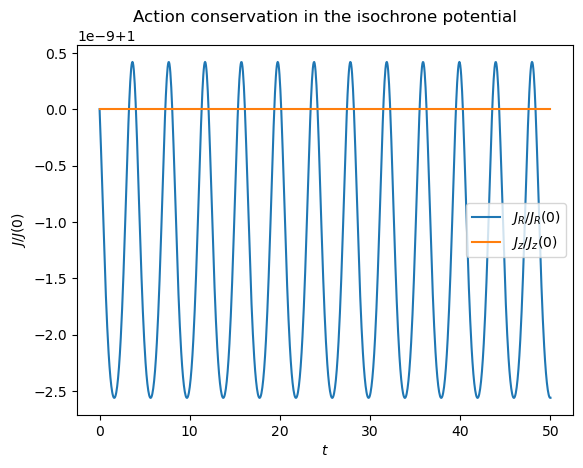

In [8]:
o = Orbit([1.0, 0.1, 1.1, 0.0, 0.05, 0.0])
ts = numpy.linspace(0.0, 50.0, 1001)
o.integrate(ts, ip)

# Compute actions at each timestep
Rs = o.R(ts)
vRs = o.vR(ts)
vTs = o.vT(ts)
zs = o.z(ts)
vzs = o.vz(ts)
phis = o.phi(ts)

jrs, jphis, jzs = aAI(Rs, vRs, vTs, zs, vzs, phis)

plt.plot(ts, jrs / jrs[0], label=r"$J_R / J_R(0)$")
plt.plot(ts, jzs / jzs[0], label=r"$J_z / J_z(0)$")
plt.xlabel(r"$t$")
plt.ylabel(r"$J / J(0)$")
plt.legend()
plt.title("Action conservation in the isochrone potential");

The actions are very well conserved, confirming the exactness
of the isochrone action-angle calculation.

### Exact inverse transform with `actionAngleIsochroneInverse`

The isochrone potential is also special because its inverse transformation is
analytical. In general, inverse action-angle objects provide these methods:

* `__call__`: returns the phase-space coordinates
* `xvFreqs`: returns the phase-space coordinates and the frequencies
* `Freqs`: returns the frequencies for the specified actions

For the isochrone case, we can use `actionAngleIsochroneInverse` to map a set
of actions and angles back to `(R, vR, vT, z, vz, phi)` and check that the
forward and inverse transformations are consistent.

In [9]:
angles = numpy.array([wr[0], wp[0], wz[0]])
R_inv, vR_inv, vT_inv, z_inv, vz_inv, phi_inv = aAII(
    jr[0], jphi[0], jz[0], angles[:1], angles[1:2], angles[2:]
)
R_xv, vR_xv, vT_xv, z_xv, vz_xv, phi_xv, Or_inv, Op_inv, Oz_inv = aAII.xvFreqs(
    jr[0], jphi[0], jz[0], angles[:1], angles[1:2], angles[2:]
)
dphi = ((phi_inv[0] - phi + numpy.pi) % (2.0 * numpy.pi)) - numpy.pi
print(
    "Recovered phase-space point:",
    f"R={R_inv[0]:.6f}, vR={vR_inv[0]:.6f}, vT={vT_inv[0]:.6f}, ",
    f"z={z_inv[0]:.6f}, vz={vz_inv[0]:.6f}, phi={phi_inv[0]:.6f}",
)
print(
    "Absolute differences:",
    numpy.abs(
        [
            R_inv[0] - R,
            vR_inv[0] - vR,
            vT_inv[0] - vT,
            z_inv[0] - z,
            vz_inv[0] - vz,
            dphi,
        ]
    ),
)
print(
    "xvFreqs matches __call__:",
    numpy.allclose(
        [R_inv[0], vR_inv[0], vT_inv[0], z_inv[0], vz_inv[0], phi_inv[0]],
        [R_xv[0], vR_xv[0], vT_xv[0], z_xv[0], vz_xv[0], phi_xv[0]],
    ),
)
print("Frequencies from xvFreqs:", (Or_inv, Op_inv, Oz_inv))
print("Frequencies from Freqs:", aAII.Freqs(jr[0], jphi[0], jz[0]))

Recovered phase-space point: R=1.000000, vR=0.100000, vT=1.100000,  z=-0.000000, vz=0.050000, phi=6.283185
Absolute differences: [2.22044605e-16 9.71445147e-16 2.22044605e-16 5.14517738e-17
 1.11022302e-16 0.00000000e+00]
xvFreqs matches __call__: True
Frequencies from xvFreqs: (np.float64(1.5597097975694187), np.float64(0.9494736851422911), np.float64(0.9494736851422911))
Frequencies from Freqs: (np.float64(1.5597097975694187), np.float64(0.9494736851422911), np.float64(0.9494736851422911))


## Spherical potentials: actionAngleSpherical

For any spherical potential, actions can be computed exactly using
`actionAngleSpherical`, which uses numerical integration of the radial
and vertical oscillations.

For non-spherical potentials, see the [Adiabatic Approximation](adiabatic.ipynb),
[Staeckel Approximation](staeckel.ipynb), and [Isochrone Approximation](isochroneapprox.ipynb)
methods. For the inverse transformation (actions to coordinates), see
[actionAngleTorus](torus.ipynb).

In [10]:
from galpy.potential import LogarithmicHaloPotential
from galpy.actionAngle import actionAngleSpherical

# Spherical logarithmic halo (q=1)
lp = LogarithmicHaloPotential(normalize=1.0, q=1.0)
aAS = actionAngleSpherical(pot=lp)

jr, jphi, jz = aAS(1.0, 0.1, 1.1, 0.0, 0.05, 0.0)
print(f"J_R = {jr[0]:.6f}, L_z = {jphi[0]:.6f}, J_z = {jz[0]:.6f}")

J_R = 0.011687, L_z = 1.100000, J_z = 0.001136


The full set of actions, frequencies, and angles:

In [11]:
# Full actions, frequencies, and angles
jr, jphi, jz, Or, Op, Oz, wr, wp, wz = aAS.actionsFreqsAngles(
    1.0, 0.1, 1.1, 0.0, 0.05, 0.0
)
print(f"Omega_R = {Or[0]:.4f}, Omega_phi = {Op[0]:.4f}, Omega_z = {Oz[0]:.4f}")

Omega_R = 1.2669, Omega_phi = 0.8947, Omega_z = 0.8947


### Verifying action conservation with actionAngleSpherical

Let's verify that actions are conserved along an orbit in the spherical logarithmic potential:

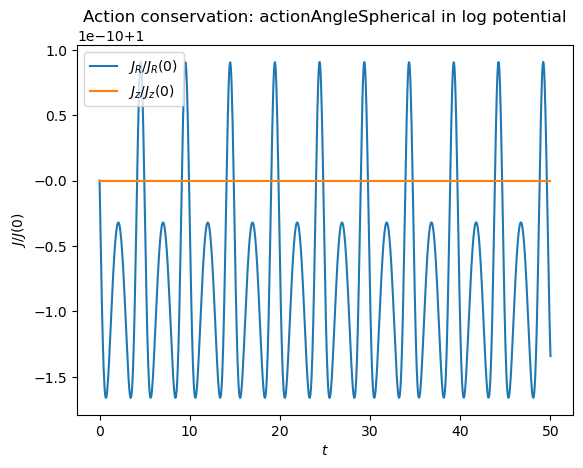

In [12]:
o_sph = Orbit([1.0, 0.1, 1.1, 0.0, 0.05, 0.0])
ts_sph = numpy.linspace(0.0, 50.0, 1001)
o_sph.integrate(ts_sph, lp)

jrs_sph, jphis_sph, jzs_sph = aAS(
    o_sph.R(ts_sph),
    o_sph.vR(ts_sph),
    o_sph.vT(ts_sph),
    o_sph.z(ts_sph),
    o_sph.vz(ts_sph),
    o_sph.phi(ts_sph),
)

plt.plot(ts_sph, jrs_sph / jrs_sph[0], label=r"$J_R / J_R(0)$")
plt.plot(ts_sph, jzs_sph / jzs_sph[0], label=r"$J_z / J_z(0)$")
plt.xlabel(r"$t$")
plt.ylabel(r"$J / J(0)$")
plt.legend()
plt.title("Action conservation: actionAngleSpherical in log potential");